# Ψεύτικα Πρόσωπα

To πρόβλημα είναι βασισμένο στο θέμα του ΠΔΤΝ: https://pdtn.gr/contests/pdtn25a/tasks/deepfakes

Θα δείτε ανάμεικτες εικόνες που δημιουργήθηκαν από τεχνητή νοημοσύνη (AI) και αληθινές φωτογραφίες. Ο στόχος σας είναι να εντοπίσετε τις ψεύτικες με ένα μοντέλο ΤΝ.

Δοκιμάστε να εκπαιδεύσετε ένα νευρωνικό (ShuffleNet v2) για να κάνετε το διαχωρισμό. Δίνονται πολλές εικόνες εκπαίδευσης τις οποίες μπορείτε να τις χρησιμοποιήσετε χωρίζοντάς τες σε train και test για να αποφύγετε το overfitting. Για να βελτιωθεί το μοντέλο σας μπορείτε να δοκιμάσετε διάφορες τεχνικές όπως augmentations στις φωτογραφίες, ξεκινώντας από ένα pretrained μοντέλο σε αντίστοιχου τύπου δεδομένα, θέτοντας κατάλληλες τιμές στο dropout κτλ. Στο site του ΠΔΤΝ υπάρχει ένα extra public dataset όπου μπορείτε να αξιολογήσετε το μοντέλο σας καθώς και ένα private στο οποίο θα γίνει η τελική αξιολόγηση.

In [1]:
import os
import numpy as np
import torch
from torchvision import transforms, datasets, models
from gdown import download
from zipfile import ZipFile
from PIL import Image

# 1. Κατεβάζουμε όλες τις εικόνες

In [2]:
def download_and_extract(id, filename, extracted_folder):
    # Κατεβάστε το αρχείο zip εάν δεν υπάρχει ήδη
    if not os.path.exists(filename):
        print("Γίνεται φόρτωση του αρχείου",filename)
        download(id=id, output=filename, quiet=False)

    # Εξαγωγή του αρχείου zip εάν ο φάκελος δεν υπάρχει ήδη
    if not os.path.exists(extracted_folder):
        print("Γίνεται αποσυμπίεση των αρχείων...")
        with ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall(extracted_folder)
main_folder = "deepfakes"
download_and_extract('16vuZcaQbd6Mmr4QZgKHJ_Y9UolOef12z', "deepfakes.zip", main_folder)

Γίνεται φόρτωση του αρχείου deepfakes.zip


Downloading...
From (original): https://drive.google.com/uc?id=16vuZcaQbd6Mmr4QZgKHJ_Y9UolOef12z
From (redirected): https://drive.google.com/uc?id=16vuZcaQbd6Mmr4QZgKHJ_Y9UolOef12z&confirm=t&uuid=ca648f3b-e548-49b6-a411-d1cf13146330
To: /content/deepfakes.zip
100%|██████████| 131M/131M [00:03<00:00, 32.9MB/s]


Γίνεται αποσυμπίεση των αρχείων...


# 2. Δημιουργούμε τα Datasets

Ορίζουμε τα train και validation Dataset και τους αντίστοιχους DataLoader

In [3]:
train_folder = os.path.join(main_folder, "train")
validation_folder = os.path.join(main_folder, "validation")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=train_folder, transform=transform)
validation_dataset = datasets.ImageFolder(root=validation_folder, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
validation_loader = torch.utils.data.DataLoader(validation_dataset, batch_size=32, shuffle=False)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(validation_dataset)}")

Train dataset size: 40000
Validation dataset size: 2000


# 3. Ορίζουμε το μοντέλο προς εκπαίδευση

**ΣΗΜΑΝΤΙΚΟ!!**

Για την άσκηση πρέπει να χρησιμοποιήσετε υποχρεωτικά το μοντέλο `shufflenet_v2_x1_0` από τα μοντέλα της `torchvision`

In [4]:
model = models.shufflenet_v2_x1_0(num_classes = 2)

if True:
    # Προαιρετικά: το αρχικοποιούμε προ-εκπαιδευμένο με βάση το ImageNet
    model = models.shufflenet_v2_x1_0(weights = models.ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1)
    # Καθώς το imagenet έχει 1000 κατηγορίες τις αλλάζουμε σε 2
    model.fc = torch.nn.Linear(model.fc.in_features, 2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.train()
model.to(device);

Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth
100%|██████████| 8.79M/8.79M [00:00<00:00, 115MB/s]


# 4. Εκπαιδεύστε το μοντέλο

Για μεγαλύτερη ταχύτητα επιλέξτε στο Colab τη χρήση GPU π.χ. T4

In [7]:
epochs = 20
model.train()

optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)
criterion = torch.nn.CrossEntropyLoss()
for epoch in range(epochs):
  rloss = 0.0 #loss for every epoch
  for inputs, labels in train_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    optimizer.zero_grad() #reset the grad
    outputs = model(inputs)
    loss = criterion(outputs, labels) #loss based on output
    loss.backward() #compute gradient
    optimizer.step() #update weights
    rloss += loss.item()

  print(f"Epoch {epoch+1}/{epochs}, Loss: {rloss / len(train_loader)}")

correct = 0
total = 0
vallos = 0

model.eval()
with torch.no_grad(): #no gradients needed for evaluation
  for inputs, labels in validation_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    vallos += loss.item()

    _, predicted = torch.max(outputs, 1)
    correct += (predicted==labels).sum().item()
    total += labels.size(0)


print(f"Validation Loss: {vallos / len(validation_loader)}")
print(f"Validation Accuracy: {100 * correct / total:.2f}%")


Epoch 1/20, Loss: 0.09896645574532449
Epoch 2/20, Loss: 0.09444695612490177
Epoch 3/20, Loss: 0.0847445629529655
Epoch 4/20, Loss: 0.07930820276085288
Epoch 5/20, Loss: 0.07317824667552486
Epoch 6/20, Loss: 0.06938648044187576
Epoch 7/20, Loss: 0.0643323279954493
Epoch 8/20, Loss: 0.057708907381724565
Epoch 9/20, Loss: 0.055247493757447225
Epoch 10/20, Loss: 0.05357174642952159
Epoch 11/20, Loss: 0.0488043401258532
Epoch 12/20, Loss: 0.0448712046377128
Epoch 13/20, Loss: 0.042740578126930634
Epoch 14/20, Loss: 0.03885690013097483
Epoch 15/20, Loss: 0.039328764697979204
Epoch 16/20, Loss: 0.037256570172979266
Epoch 17/20, Loss: 0.036640154063576486
Epoch 18/20, Loss: 0.036298712613014504
Epoch 19/20, Loss: 0.033312424875871514
Epoch 20/20, Loss: 0.03166853991968092
Validation Loss: 0.14569891447068326
Validation Accuracy: 95.45%


In [8]:
torch.save(model.state_dict(), "model.pth")


# 5. Εξαγωγή των βαρών

Σώστε τα βάρη του νευρωνικού ως `.png` εικόνα και ανεβάστε την εικόνα στο site για υποβολή.

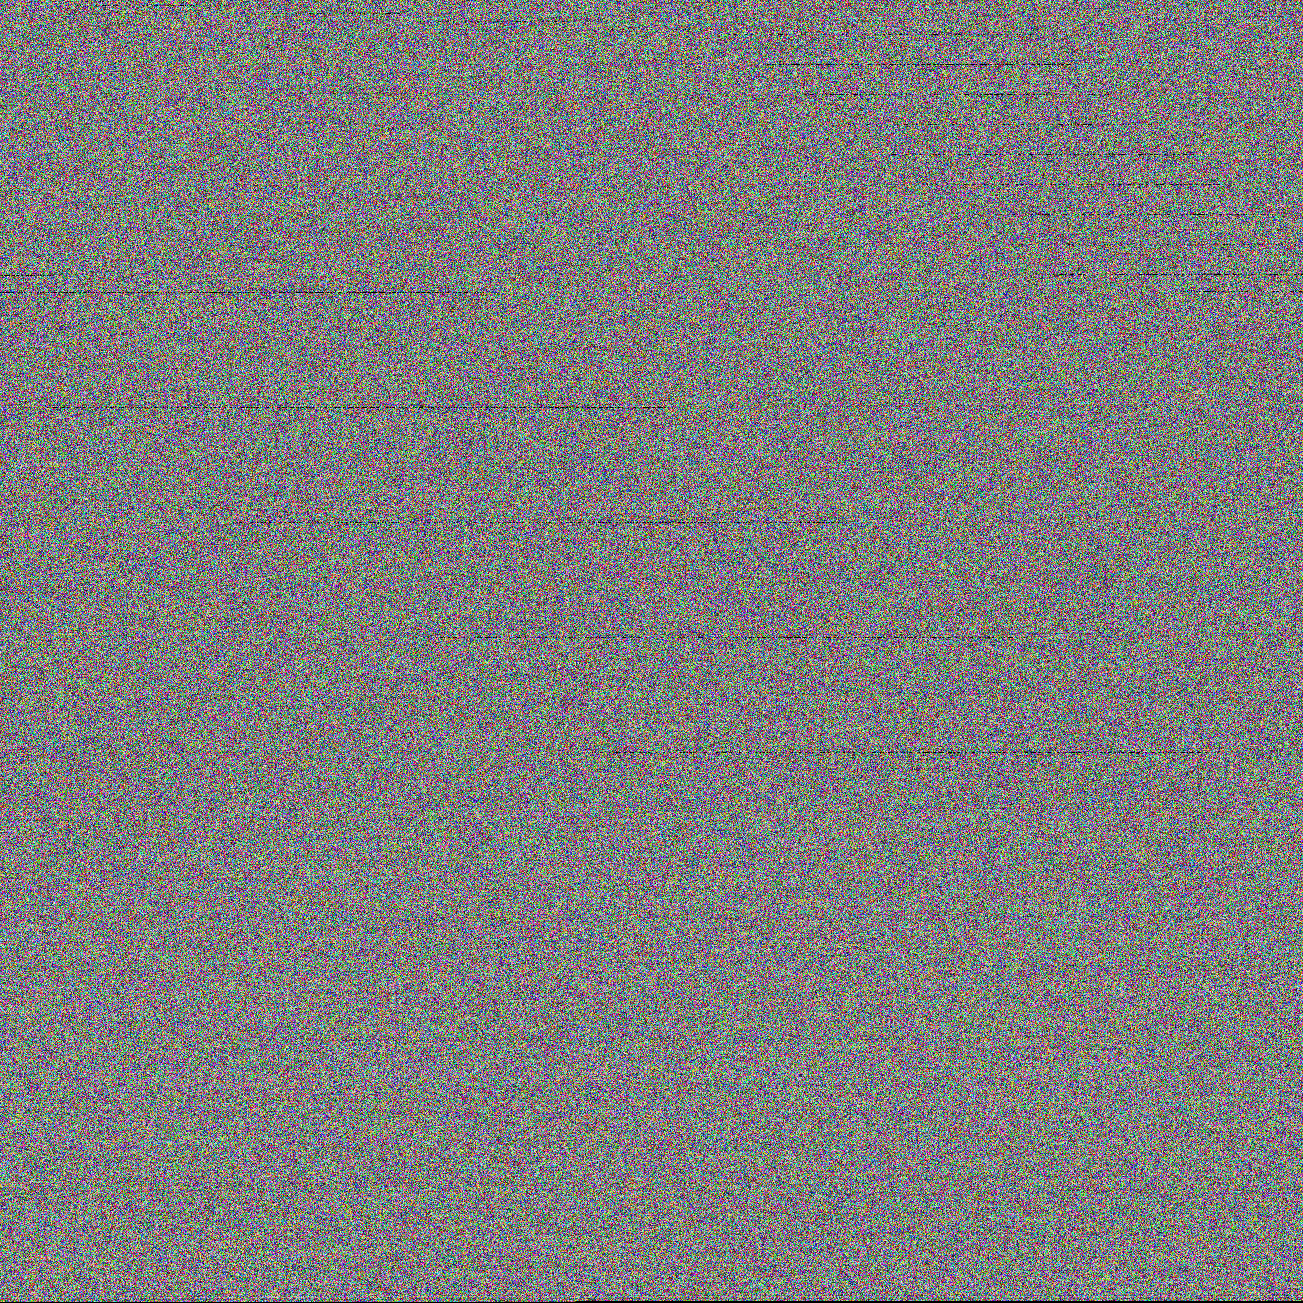

In [9]:
def modelToImage(model):
    model.eval()
    state_dict = model.state_dict()
    weights = []
    for key, tensor in state_dict.items():
        if 'num_batches_tracked' in key: continue
        w = tensor.flatten().cpu().numpy()
        weights.append(w)
    weights = np.concatenate(weights).astype(np.float32)
    byte_array = weights.view(np.uint8)
    L = len(byte_array) / 3
    N = int( np.ceil( np.sqrt(L) ) )
    padding = 3*N*N - len(byte_array)
    byte_array = np.pad(byte_array, (0, padding), mode='constant')
    img = Image.fromarray(byte_array.reshape(N,N,3).astype(np.uint8), mode='RGB')
    img.save("weights.png")
    return img

modelToImage(model)

#score 158/162